In [1]:
!pip install "gymnasium[mujoco]"

In [2]:
import math
from dataclasses import dataclass

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.notebook import tqdm

In [3]:
@dataclass
class Args:
    """PPO hyperparameters for HalfCheetah-v5."""

    env_id: str = "HalfCheetah-v5"
    num_envs: int = 8
    num_steps: int = 2048
    total_timesteps: int = 3_000_000
    update_epochs: int = 10
    num_minibatches: int = 32
    learning_rate: float = 3e-4
    anneal_lr: bool = True
    gamma: float = 0.99
    gae_lambda: float = 0.95
    clip_eps: float = 0.2
    ent_coef: float = 0.0
    vf_coef: float = 0.5
    max_grad_norm: float = 0.5
    target_kl: float | None = 0.015
    hidden_dim: int = 256
    action_std_init: float = 0.6
    value_clip: bool = True
    clip_vloss: float = 0.2
    seed: int = 42


args = Args()

In [4]:
class ActorCritic(nn.Module):
    """Shared backbone actor-critic network for continuous control."""

    def __init__(self, obs_dim: int, action_dim: int, action_low: np.ndarray, action_high: np.ndarray):
        """Initialize the Actor-Critic network.

        Args:
            obs_dim: Dimension of the observation space.
            action_dim: Dimension of the action space.
            action_low: Minimum values for the action space.
            action_high: Maximum values for the action space.
        """
        super().__init__()
        self.action_dim = action_dim

        self.backbone = nn.Sequential(
            nn.Linear(obs_dim, args.hidden_dim),
            nn.Tanh(),
            nn.Linear(args.hidden_dim, args.hidden_dim),
            nn.Tanh(),
        )
        self.actor_mean = nn.Linear(args.hidden_dim, action_dim)
        self.actor_logstd = nn.Parameter(
            torch.ones(1, action_dim) * np.log(args.action_std_init)
        )
        self.critic = nn.Linear(args.hidden_dim, 1)

        action_low_t = torch.as_tensor(action_low, dtype=torch.float32)
        action_high_t = torch.as_tensor(action_high, dtype=torch.float32)
        self.register_buffer("action_scale", (action_high_t - action_low_t) / 2.0)
        self.register_buffer("action_bias", (action_high_t + action_low_t) / 2.0)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Forward pass returning action mean, log std, and value.

        Args:
            x: Observation tensor.

        Returns:
            Tuple containing (action_mean, action_logstd, value).
        """
        latent = self.backbone(x)
        action_mean = self.actor_mean(latent)
        action_logstd = self.actor_logstd.expand_as(action_mean)
        value = self.critic(latent)
        return action_mean, action_logstd, torch.squeeze(value, dim=-1)

    def get_value(self, x: torch.Tensor) -> torch.Tensor:
        """Compute state value.

        Args:
            x: Observation tensor.

        Returns:
            Value of the state as a tensor.
        """
        latent = self.backbone(x)
        return torch.squeeze(self.critic(latent), dim=-1)

In [5]:
def _gaussian_log_prob(dist: torch.distributions.Normal, action: torch.Tensor) -> torch.Tensor:
    """Return summed log-probability across action dimensions."""
    return dist.log_prob(action).sum(dim=-1)


def _gaussian_entropy(dist: torch.distributions.Normal) -> torch.Tensor:
    """Return summed entropy across action dimensions."""
    return dist.entropy().sum(dim=-1)


def select_action(
    model: ActorCritic,
    obs: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Sample action from a Gaussian policy.

    Returns:
        Tuple of (env_action, log_prob, value, raw_action)
    """
    action_mean, action_logstd, value = model(obs)
    action_std = action_logstd.exp()
    dist = torch.distributions.Normal(action_mean, action_std)
    raw_action = dist.sample()
    log_prob = _gaussian_log_prob(dist, raw_action)
    env_action = torch.tanh(raw_action) * model.action_scale + model.action_bias
    return env_action, log_prob, value, raw_action

In [6]:
def compute_gae(
    values: torch.Tensor,
    rewards: torch.Tensor,
    dones: torch.Tensor,
    next_value: torch.Tensor,
    gamma: float = 0.99,
    lam: float = 0.95,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Compute Generalized Advantage Estimation (GAE)."""
    num_steps = values.shape[0]
    advantages = torch.zeros_like(rewards)
    lastgaelam = torch.zeros_like(next_value)

    for t in reversed(range(num_steps)):
        if t == num_steps - 1:
            nextvalues = next_value
        else:
            nextvalues = values[t + 1]

        nonterminal = 1.0 - dones[t]
        delta = rewards[t] + gamma * nextvalues * nonterminal - values[t]
        lastgaelam = delta + gamma * lam * nonterminal * lastgaelam
        advantages[t] = lastgaelam

    returns = advantages + values
    return returns, advantages

In [7]:
def ppo_loss_fn(
    model: ActorCritic,
    batch: tuple[torch.Tensor, ...],
    clip_eps: float = 0.2,
    ent_coef: float = 0.0,
    vf_coef: float = 0.5,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Compute PPO loss components for continuous control.

    Args:
        model: ActorCritic network
        batch: Tuple of (states, raw_actions, old_log_probs, advantages, returns, old_values)

    Returns:
        Tuple of (total_loss, policy_loss, value_loss, entropy_loss, approx_kl)
    """
    states, raw_actions, old_log_probs, advantages, returns, old_values = batch

    action_mean, action_logstd, values = model(states)
    action_std = action_logstd.exp()
    dist = torch.distributions.Normal(action_mean, action_std)

    new_log_probs = _gaussian_log_prob(dist, raw_actions)
    entropy = _gaussian_entropy(dist).mean()

    ratio = torch.exp(new_log_probs - old_log_probs)
    clipped_ratio = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps)
    policy_loss = -torch.min(ratio * advantages, clipped_ratio * advantages).mean()

    if args.value_clip:
        value_pred_clipped = old_values + torch.clamp(values - old_values, -args.clip_vloss, args.clip_vloss)
        value_loss_unclipped = (values - returns) ** 2
        value_loss_clipped = (value_pred_clipped - returns) ** 2
        value_loss = 0.5 * torch.max(value_loss_unclipped, value_loss_clipped).mean()
    else:
        value_loss = 0.5 * F.mse_loss(values, returns)

    entropy_loss = -ent_coef * entropy
    total_loss = policy_loss + vf_coef * value_loss + entropy_loss

    approx_kl = (old_log_probs - new_log_probs).mean()
    return total_loss, policy_loss, value_loss, entropy_loss, approx_kl


def update_step(
    model: ActorCritic,
    optimizer: torch.optim.Optimizer,
    batch: tuple[torch.Tensor, ...],
    clip_eps: float,
) -> tuple[float, tuple[float, float, float, float]]:
    """Single PPO update step."""
    optimizer.zero_grad()
    loss, p_loss, v_loss, e_loss, approx_kl = ppo_loss_fn(
        model,
        batch,
        clip_eps,
        ent_coef=args.ent_coef,
        vf_coef=args.vf_coef,
    )
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), args.max_grad_norm)
    optimizer.step()
    return loss.item(), (p_loss.item(), v_loss.item(), e_loss.item(), approx_kl.item())

In [8]:
def save_model(model: ActorCritic, save_path: str = "./ppo_halfcheetah_model.pth") -> None:
    """Save trained model state dict."""
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")

def set_seed(seed: int) -> None:
    """Set random seeds for reproducibility."""
    np.random.seed(seed)
    torch.manual_seed(seed)


In [11]:
def train() -> tuple[ActorCritic, dict]:
    """Train PPO agent on HalfCheetah-v5.

    Returns:
        Tuple containing (trained_model, training_history).
    """
    set_seed(args.seed)
    envs = gym.make_vec(args.env_id, num_envs=args.num_envs)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ActorCritic(
        envs.single_observation_space.shape[0],
        envs.single_action_space.shape[0],
        envs.single_action_space.low,
        envs.single_action_space.high,
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate, eps=1e-5)

    global_step = 0
    num_updates = args.total_timesteps // (args.num_envs * args.num_steps)
    batch_size = args.num_envs * args.num_steps
    minibatch_size = batch_size // args.num_minibatches

    history = {"step": [], "reward": [], "loss": [], "episodic_return": [], "approx_kl": []}
    obs, _ = envs.reset(seed=args.seed)
    obs = torch.as_tensor(obs, dtype=torch.float32, device=device)

    print(f"Starting training on {device} for {args.env_id}...")

    for update in tqdm(range(1, num_updates + 1)):
        if args.anneal_lr:
            frac = 1.0 - (update - 1.0) / num_updates
            optimizer.param_groups[0]["lr"] = frac * args.learning_rate

        b_obs = torch.zeros((args.num_steps, args.num_envs) + envs.single_observation_space.shape, device=device)
        b_raw_actions = torch.zeros((args.num_steps, args.num_envs) + envs.single_action_space.shape, device=device)
        b_logprobs = torch.zeros((args.num_steps, args.num_envs), device=device)
        b_rewards = torch.zeros((args.num_steps, args.num_envs), device=device)
        b_dones = torch.zeros((args.num_steps, args.num_envs), device=device)
        b_values = torch.zeros((args.num_steps, args.num_envs), device=device)

        episodic_returns = []

        for step in range(args.num_steps):
            global_step += args.num_envs
            b_obs[step] = obs
            with torch.no_grad():
                action, logprob, value, raw_action = select_action(model, obs)
                b_values[step] = value
            b_raw_actions[step] = raw_action
            b_logprobs[step] = logprob

            next_obs, reward, terminations, truncations, infos = envs.step(action.cpu().numpy())
            done = np.logical_or(terminations, truncations)

            b_rewards[step] = torch.as_tensor(reward, dtype=torch.float32, device=device)
            b_dones[step] = torch.as_tensor(done, dtype=torch.float32, device=device)
            obs = torch.as_tensor(next_obs, dtype=torch.float32, device=device)

            if isinstance(infos, dict) and "final_info" in infos:
                for final_info in infos["final_info"]:
                    if final_info is not None and "episode" in final_info:
                        episodic_returns.append(final_info["episode"]["r"])

        with torch.no_grad():
            next_value = model.get_value(obs)
            returns, advantages = compute_gae(
                b_values,
                b_rewards,
                b_dones,
                next_value,
                gamma=args.gamma,
                lam=args.gae_lambda,
            )

        f_obs = b_obs.reshape(-1, *envs.single_observation_space.shape)
        f_raw_actions = b_raw_actions.reshape(-1, *envs.single_action_space.shape)
        f_logprobs = b_logprobs.reshape(-1)
        f_advantages = advantages.reshape(-1)
        f_advantages = (f_advantages - f_advantages.mean()) / (f_advantages.std() + 1e-8)
        f_returns = returns.reshape(-1)
        f_values = b_values.reshape(-1)

        inds = np.arange(batch_size)
        loss_val = 0.0
        approx_kl_val = 0.0
        should_stop = False

        for _epoch in range(args.update_epochs):
            np.random.shuffle(inds)
            for start in range(0, batch_size, minibatch_size):
                end = start + minibatch_size
                mb_inds = inds[start:end]
                mb_batch = (
                    f_obs[mb_inds],
                    f_raw_actions[mb_inds],
                    f_logprobs[mb_inds],
                    f_advantages[mb_inds],
                    f_returns[mb_inds],
                    f_values[mb_inds],
                )
                loss_val, (_, _, _, approx_kl_val) = update_step(model, optimizer, mb_batch, args.clip_eps)
                if args.target_kl is not None and approx_kl_val > args.target_kl:
                    should_stop = True
                    break
            if should_stop:
                break

        mean_reward = b_rewards.sum(0).mean().item()
        mean_episodic_return = float(np.mean(episodic_returns)) if episodic_returns else float("nan")
        history["step"].append(global_step)
        history["reward"].append(mean_reward)
        history["loss"].append(loss_val)
        history["episodic_return"].append(mean_episodic_return)
        history["approx_kl"].append(approx_kl_val)

        if update % 10 == 0:
            print(
                f"Update {update}/{num_updates} | Step {global_step} | "
                f"Loss: {loss_val:.4f} | Mean rollout reward: {mean_reward:.2f} | "
                f"KL: {approx_kl_val:.5f}"
            )

        if update % 50 == 0:
            save_model(model, f"ppo_halfcheetah_checkpoint_{update}.pth")

    envs.close()
    save_model(model, "ppo_halfcheetah_final.pth")
    return model, history

In [12]:
model, history = train()

Starting training on cpu for HalfCheetah-v5...


  0%|          | 0/183 [00:00<?, ?it/s]

Update 10/183 | Step 163840 | Loss: 4.7450 | Mean rollout reward: -207.45 | KL: 0.03060
Update 20/183 | Step 327680 | Loss: 3.9726 | Mean rollout reward: -173.64 | KL: 0.02286
Update 30/183 | Step 491520 | Loss: 3.7640 | Mean rollout reward: -171.50 | KL: 0.02401
Update 40/183 | Step 655360 | Loss: 3.7789 | Mean rollout reward: -212.33 | KL: 0.01936
Update 50/183 | Step 819200 | Loss: 2.4642 | Mean rollout reward: -123.60 | KL: 0.01579
Model saved to ppo_halfcheetah_checkpoint_50.pth
Update 60/183 | Step 983040 | Loss: 3.0620 | Mean rollout reward: -42.39 | KL: 0.01790
Update 70/183 | Step 1146880 | Loss: 3.9747 | Mean rollout reward: 111.69 | KL: 0.01520
Update 80/183 | Step 1310720 | Loss: 5.6625 | Mean rollout reward: 102.76 | KL: 0.01533
Update 90/183 | Step 1474560 | Loss: 8.8984 | Mean rollout reward: 239.68 | KL: 0.01788
Update 100/183 | Step 1638400 | Loss: 9.6113 | Mean rollout reward: 448.68 | KL: 0.01539
Model saved to ppo_halfcheetah_checkpoint_100.pth
Update 110/183 | Step

In [13]:
def evaluate(checkpoint_path: str, num_episodes: int = 3, render: bool = False) -> list[float]:
    """Load a model and run evaluation episodes."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    temp_env = gym.make(args.env_id)
    obs_dim = temp_env.observation_space.shape[0]
    action_dim = temp_env.action_space.shape[0]
    action_low = temp_env.action_space.low
    action_high = temp_env.action_space.high
    temp_env.close()

    model = ActorCritic(obs_dim, action_dim, action_low, action_high).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    returns = []
    render_mode = "human" if render else None
    env = gym.make(args.env_id, render_mode=render_mode)

    for episode in range(num_episodes):
        obs, _ = env.reset(seed=args.seed + episode)
        done = False
        truncated = False
        total_reward = 0.0

        while not (done or truncated):
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                action_mean, _, _ = model(obs_t)
                action = torch.tanh(action_mean) * model.action_scale + model.action_bias
            obs, reward, done, truncated, _ = env.step(action.squeeze(0).cpu().numpy())
            total_reward += reward

        returns.append(total_reward)
        print(f"Episode {episode + 1}: return={total_reward:.2f}")

    env.close()
    return returns

In [ ]:
def plot_training_results(history: dict, window: int = 10) -> None:
    """Plot training rewards with a rolling mean for smoothing."""
    import matplotlib.pyplot as plt
    import pandas as pd

    fig, ax1 = plt.subplots(figsize=(12, 5))

    rewards_series = pd.Series(history["reward"])
    rolling_mean = rewards_series.rolling(window=window).mean()

    ax1.set_xlabel("Steps")
    ax1.set_ylabel("Reward")

    ax1.plot(history["step"], history["reward"], label="Raw Reward", alpha=0.3)
    ax1.plot(history["step"], rolling_mean, label=f"Rolling Mean (w={window})", linewidth=2)

    plt.title("PPO Training Performance: HalfCheetah-v5")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

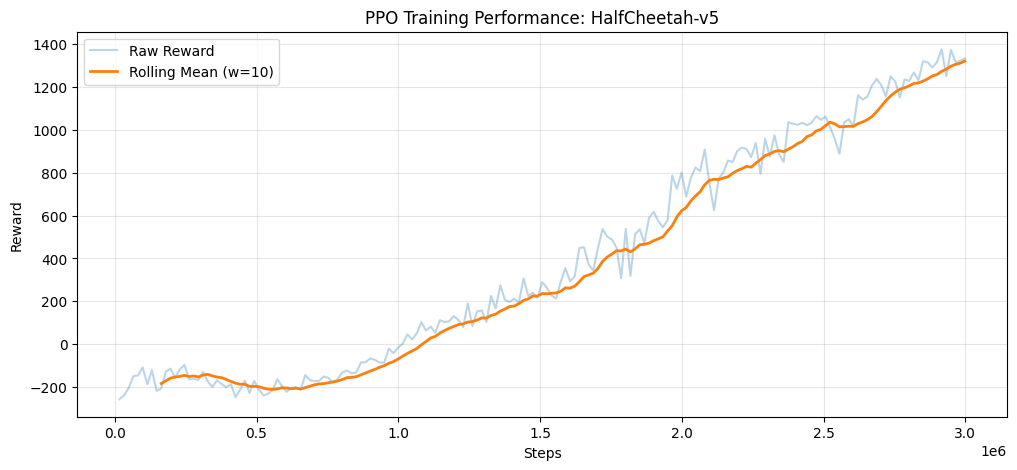

In [24]:
plot_training_results(history)

In [ ]:
import imageio
import os
import torch
import gymnasium as gym
import numpy as np
from IPython.display import Image, display

def record_gif(checkpoint_path, filename='simulation.gif'):
    """Load a model from file and record a simulation GIF using EGL for headless rendering."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    temp_env = gym.make(args.env_id)
    obs_dim = temp_env.observation_space.shape[0]
    action_dim = temp_env.action_space.shape[0]
    action_low = temp_env.action_space.low
    action_high = temp_env.action_space.high
    temp_env.close()

    model = ActorCritic(
        obs_dim,
        action_dim,
        action_low,
        action_high,
    ).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    env = gym.make(args.env_id, render_mode='rgb_array')
    obs, _ = env.reset(seed=42)
    frames = []
    done = False
    truncated = False
    total_reward = 0

    print(f"Simulating using {checkpoint_path}...")
    while not (done or truncated):
        frames.append(env.render())
        with torch.no_grad():
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            action_mean, _, _ = model(obs_t)
            action = torch.tanh(action_mean) * model.action_scale + model.action_bias

        obs, reward, done, truncated, _ = env.step(action.squeeze(0).cpu().numpy())
        total_reward += reward

    env.close()
    print(f"Total Reward: {total_reward:.2f}")
    imageio.mimsave(filename, frames, fps=24)
    return filename

In [ ]:
import os
os.environ['MUJOCO_GL'] = 'egl'

gif_filename = 'halfcheetah_simulation.gif'
record_gif('/content/ppo_halfcheetah_final.pth', filename=gif_filename)
print(f'Simulation saved to {os.path.abspath(gif_filename)}')

Simulating using /content/ppo_halfcheetah_final.pth...
Total Reward: 668.93
Simulation saved to /content/halfcheetah_simulation.gif
